<a href="https://colab.research.google.com/github/AvishkaPrabudi/Real_Time_Cinema_prediction-platform/blob/main/Real_Time_Cinema_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - Upload CSV file in Colab
from google.colab import files
uploaded = files.upload()

Saving master_dataset.csv to master_dataset.csv


In [2]:
# Cell 2 - Import libraries and load dataset
import pandas as pd
import numpy as np

df = pd.read_csv("master_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (666, 23)


,date,show_time,day_of_week,is_weekend,screen_name,total_seats,movie_id,movie_title,genre,tmdb_rating,...,seats_available,occupancy_rate,occupancy_level,temperature,humidity,precipitation,weather_condition,wind_speed,source,weather_impact
0,2025-09-20,22:00,Saturday,1,Screen 1,150,1159559,Scream 7,Unknown,5.8,...,13,91.62,high,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0
1,2025-09-20,13:00,Saturday,1,Screen 2,100,1171145,Crime 101,Unknown,7.0,...,28,72.32,medium,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0
2,2025-09-20,22:00,Saturday,1,Screen 3,80,1266127,Ready or Not: Here I Come,Unknown,7.5,...,2,98.00,high,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0
3,2025-09-23,10:00,Tuesday,0,Screen 1,150,83533,Avatar: Fire and Ash,Unknown,7.3,...,73,51.56,medium,26.2,80,7.6,Rain,18.8,openmeteo_historical,0.0
4,2025-09-23,16:00,Tuesday,0,Screen 3,80,561362,Rust Creek,Unknown,6.3,...,43,46.79,medium,26.2,80,7.6,Rain,18.8,openmeteo_historical,0.0


In [3]:
# Cell 3 - Basic info
print(df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())
print("\nData types:\n")
print(df.dtypes)

['date', 'show_time', 'day_of_week', 'is_weekend', 'screen_name', 'total_seats', 'movie_id', 'movie_title', 'genre', 'tmdb_rating', 'release_date', 'days_since_release', 'tickets_booked', 'seats_available', 'occupancy_rate', 'occupancy_level', 'temperature', 'humidity', 'precipitation', 'weather_condition', 'wind_speed', 'source', 'weather_impact']

Missing values:

date                  0
show_time             0
day_of_week           0
is_weekend            0
screen_name           0
total_seats           0
movie_id              0
movie_title           0
genre                 0
tmdb_rating           0
release_date          0
days_since_release    0
tickets_booked        0
seats_available       0
occupancy_rate        0
occupancy_level       0
temperature           0
humidity              0
precipitation         0
weather_condition     0
wind_speed            0
source                0
weather_impact        0
dtype: int64

Data types:

date                   object
show_time             

In [4]:
# Cell 4 - Remove columns that cause data leakage
cols_to_remove = ['tickets_booked', 'seats_available', 'occupancy_rate']
df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['date', 'show_time', 'day_of_week', 'is_weekend', 'screen_name', 'total_seats', 'movie_id', 'movie_title', 'genre', 'tmdb_rating', 'release_date', 'days_since_release', 'occupancy_level', 'temperature', 'humidity', 'precipitation', 'weather_condition', 'wind_speed', 'source', 'weather_impact']


In [6]:
# Cell 5 - Feature engineering
# Convert show_time to hour if show_time exists
if 'show_time' in df.columns:
    df['show_time'] = pd.to_datetime(df['show_time'], errors='coerce')
    df['show_hour'] = df['show_time'].dt.hour.fillna(0).astype(int)

# Convert date to month if date exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['show_month'] = df['date'].dt.month.fillna(0).astype(int)

# Convert release_date to days_since_release if needed
if 'release_date' in df.columns and 'date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    if 'days_since_release' not in df.columns:
        df['days_since_release'] = (df['date'] - df['release_date']).dt.days

# Optional engineered features
if 'show_hour' in df.columns:
    df['is_evening'] = (df['show_hour'] >= 18).astype(int)
    df['is_peak_hour'] = df['show_hour'].between(18, 22).astype(int)

df.head()

,date,show_time,day_of_week,is_weekend,screen_name,total_seats,movie_id,movie_title,genre,tmdb_rating,...,humidity,precipitation,weather_condition,wind_speed,source,weather_impact,show_hour,show_month,is_evening,is_peak_hour
0,2025-09-20,2026-04-07 22:00:00,Saturday,1,Screen 1,150,1159559,Scream 7,Unknown,5.8,...,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,22,9,1,1
1,2025-09-20,2026-04-07 13:00:00,Saturday,1,Screen 2,100,1171145,Crime 101,Unknown,7.0,...,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,13,9,0,0
2,2025-09-20,2026-04-07 22:00:00,Saturday,1,Screen 3,80,1266127,Ready or Not: Here I Come,Unknown,7.5,...,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,22,9,1,1
3,2025-09-23,2026-04-07 10:00:00,Tuesday,0,Screen 1,150,83533,Avatar: Fire and Ash,Unknown,7.3,...,80,7.6,Rain,18.8,openmeteo_historical,0.0,10,9,0,0
4,2025-09-23,2026-04-07 16:00:00,Tuesday,0,Screen 3,80,561362,Rust Creek,Unknown,6.3,...,80,7.6,Rain,18.8,openmeteo_historical,0.0,16,9,0,0


In [7]:
# Cell 6 - Set target column
target_col = 'occupancy_level'

print("Unique target values:")
print(df[target_col].value_counts())

Unique target values:
occupancy_level
medium    373
high      165
low       128
Name: count, dtype: int64


In [8]:
# Cell 7 - Remove unnecessary raw columns
remove_extra = [target_col, 'movie_title', 'date', 'release_date', 'show_time']
X = df.drop(columns=[c for c in remove_extra if c in df.columns])
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Features shape: (666, 19)
Target shape: (666,)


,day_of_week,is_weekend,screen_name,total_seats,movie_id,genre,tmdb_rating,days_since_release,temperature,humidity,precipitation,weather_condition,wind_speed,source,weather_impact,show_hour,show_month,is_evening,is_peak_hour
0,Saturday,1,Screen 1,150,1159559,Unknown,5.8,26,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,22,9,1,1
1,Saturday,1,Screen 2,100,1171145,Unknown,7.0,42,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,13,9,0,0
2,Saturday,1,Screen 3,80,1266127,Unknown,7.5,5,26.6,80,5.8,Drizzle,17.3,openmeteo_historical,0.0,22,9,1,1
3,Tuesday,0,Screen 1,150,83533,Unknown,7.3,98,26.2,80,7.6,Rain,18.8,openmeteo_historical,0.0,10,9,0,0
4,Tuesday,0,Screen 3,80,561362,Unknown,6.3,2637,26.2,80,7.6,Rain,18.8,openmeteo_historical,0.0,16,9,0,0


In [9]:
# Cell 8 - One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X.shape)
X.head()

Encoded feature shape: (666, 30)


,is_weekend,total_seats,movie_id,tmdb_rating,days_since_release,temperature,humidity,precipitation,wind_speed,weather_impact,...,screen_name_Screen 2,screen_name_Screen 3,weather_condition_Heavy Drizzle,weather_condition_Heavy Rain,weather_condition_Light Drizzle,weather_condition_Light Rain,weather_condition_Mainly Clear,weather_condition_Overcast,weather_condition_Partly Cloudy,weather_condition_Rain
0,1,150,1159559,5.8,26,26.6,80,5.8,17.3,0.0,...,False,False,False,False,False,False,False,False,False,False
1,1,100,1171145,7.0,42,26.6,80,5.8,17.3,0.0,...,True,False,False,False,False,False,False,False,False,False
2,1,80,1266127,7.5,5,26.6,80,5.8,17.3,0.0,...,False,True,False,False,False,False,False,False,False,False
3,0,150,83533,7.3,98,26.2,80,7.6,18.8,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,80,561362,6.3,2637,26.2,80,7.6,18.8,0.0,...,False,True,False,False,False,False,False,False,False,True


In [10]:
# Cell 9 - Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (532, 30)
X_test : (134, 30)


In [11]:
# Cell 10 - Train model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [12]:
# Cell 11 - Predictions and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7985074626865671

Classification Report:

              precision    recall  f1-score   support

        high       0.90      0.79      0.84        33
         low       0.68      0.65      0.67        26
      medium       0.80      0.85      0.83        75

    accuracy                           0.80       134
   macro avg       0.79      0.77      0.78       134
weighted avg       0.80      0.80      0.80       134


Confusion Matrix:

[[26  0  7]
 [ 0 17  9]
 [ 3  8 64]]


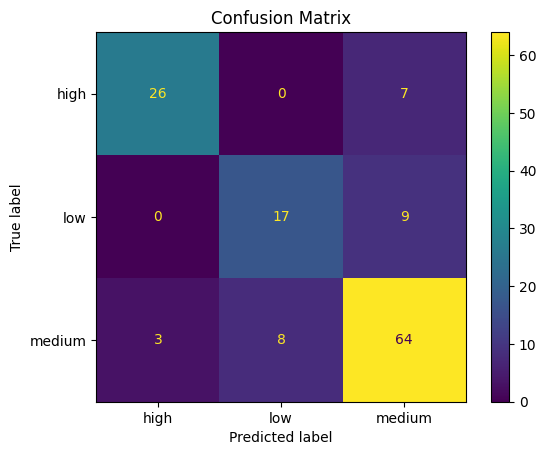

In [13]:
# Cell 12 - Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Cell 13 - Feature importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                 Feature  Importance
4     days_since_release    0.210308
3            tmdb_rating    0.105561
0             is_weekend    0.078721
2               movie_id    0.077540
10             show_hour    0.065933
8             wind_speed    0.062451
7          precipitation    0.050789
5            temperature    0.049429
11            show_month    0.032969
16    day_of_week_Sunday    0.030544
13          is_peak_hour    0.029938
12            is_evening    0.027255
6               humidity    0.018216
1            total_seats    0.017977
15  day_of_week_Saturday    0.017674


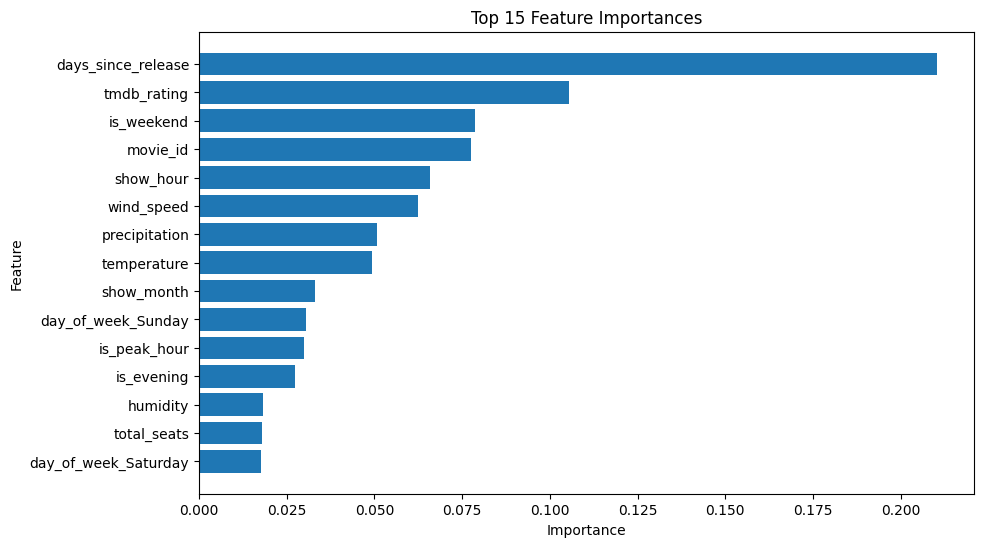

In [15]:
# Cell 14 - Plot top 15 important features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [16]:
# Cell 15 - Install XGBoost
!pip install xgboost -q

In [17]:
# Cell 16 - Encode target labels for XGBoost
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:
# Cell 17 - Train XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
# Cell 18 - Evaluate XGBoost
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = xgb_model.predict(X_test_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=label_encoder.classes_))

XGBoost Accuracy: 0.8134328358208955

Classification Report:

              precision    recall  f1-score   support

        high       0.82      0.85      0.84        33
         low       0.71      0.77      0.74        26
      medium       0.85      0.81      0.83        75

    accuracy                           0.81       134
   macro avg       0.80      0.81      0.80       134
weighted avg       0.82      0.81      0.81       134



In [20]:
# Cell 19 - Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.7782754364309645


In [21]:
# Cell 20 - Best tuned model evaluation
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Tuned Model Accuracy: 0.8134328358208955

Classification Report:

              precision    recall  f1-score   support

        high       0.87      0.82      0.84        33
         low       0.72      0.69      0.71        26
      medium       0.82      0.85      0.84        75

    accuracy                           0.81       134
   macro avg       0.80      0.79      0.80       134
weighted avg       0.81      0.81      0.81       134



In [22]:
# Cell 21 - Save model
import joblib

joblib.dump(best_model, "cinema_crowd_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [23]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy Percentage:", acc * 100)

Accuracy Percentage: 79.8507462686567


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.90      0.79      0.84        33
         low       0.68      0.65      0.67        26
      medium       0.80      0.85      0.83        75

    accuracy                           0.80       134
   macro avg       0.79      0.77      0.78       134
weighted avg       0.80      0.80      0.80       134

[[26  0  7]
 [ 0 17  9]
 [ 3  8 64]]


In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_sm).value_counts())

occupancy_level
high      298
medium    298
low       298
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_sm, y_train_sm)
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8134328358208955
              precision    recall  f1-score   support

        high       0.84      0.82      0.83        33
         low       0.73      0.73      0.73        26
      medium       0.83      0.84      0.83        75

    accuracy                           0.81       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.81      0.81      0.81       134

[[27  0  6]
 [ 0 19  7]
 [ 5  7 63]]


In [27]:
df['is_evening'] = (df['show_hour'] >= 18).astype(int)
df['is_peak_hour'] = df['show_hour'].between(18, 22).astype(int)
df['bad_weather'] = (df['precipitation'] > 5).astype(int)
df['very_bad_weather'] = ((df['precipitation'] > 10) | (df['wind_speed'] > 25)).astype(int)
df['high_humidity'] = (df['humidity'] > 80).astype(int)
df['high_rating'] = (df['tmdb_rating'] >= 7.5).astype(int)
df['new_release'] = (df['days_since_release'] <= 14).astype(int)
df['weekend_evening'] = ((df['is_weekend'] == 1) & (df['show_hour'] >= 18)).astype(int)

In [28]:
!pip install xgboost imbalanced-learn -q

In [30]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

target_col = 'occupancy_level'
remove_extra = [target_col, 'movie_title', 'date', 'release_date', 'show_time']
X = df.drop(columns=[c for c in remove_extra if c in df.columns])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7985074626865671
              precision    recall  f1-score   support

        high       0.82      0.82      0.82        33
         low       0.68      0.81      0.74        26
      medium       0.84      0.79      0.81        75

    accuracy                           0.80       134
   macro avg       0.78      0.80      0.79       134
weighted avg       0.80      0.80      0.80       134

[[27  0  6]
 [ 0 21  5]
 [ 6 10 59]]


In [31]:
!pip install xgboost -q

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Define X and y again
target_col = 'occupancy_level'
remove_extra = [target_col, 'movie_title', 'date', 'release_date', 'show_time']
X = df.drop(columns=[c for c in remove_extra if c in df.columns])
y = df[target_col]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8134328358208955
              precision    recall  f1-score   support

        high       0.83      0.88      0.85        33
         low       0.70      0.73      0.72        26
      medium       0.85      0.81      0.83        75

    accuracy                           0.81       134
   macro avg       0.79      0.81      0.80       134
weighted avg       0.81      0.81      0.81       134

[[29  0  4]
 [ 0 19  7]
 [ 6  8 61]]


In [32]:
df['is_evening'] = (df['show_hour'] >= 18).astype(int)
df['is_peak_hour'] = df['show_hour'].between(18, 22).astype(int)
df['bad_weather'] = (df['precipitation'] > 5).astype(int)
df['very_bad_weather'] = ((df['precipitation'] > 10) | (df['wind_speed'] > 25)).astype(int)
df['high_humidity'] = (df['humidity'] > 80).astype(int)
df['high_rating'] = (df['tmdb_rating'] >= 7.5).astype(int)
df['new_release'] = (df['days_since_release'] <= 14).astype(int)
df['weekend_evening'] = ((df['is_weekend'] == 1) & (df['show_hour'] >= 18)).astype(int)
df['weekend_peak'] = ((df['is_weekend'] == 1) & (df['show_hour'].between(18,22))).astype(int)

In [33]:
!pip install xgboost -q

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

target_col = 'occupancy_level'
remove_extra = [target_col, 'movie_title', 'date', 'release_date', 'show_time']
X = df.drop(columns=[c for c in remove_extra if c in df.columns])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.7950978663375067
Test Accuracy: 0.8134328358208955
              precision    recall  f1-score   support

        high       0.81      0.88      0.84        33
         low       0.71      0.77      0.74        26
      medium       0.86      0.80      0.83        75

    accuracy                           0.81       134
   macro avg       0.79      0.82      0.80       134
weighted avg       0.82      0.81      0.81       134

[[29  0  4]
 [ 0 20  6]
 [ 7  8 60]]


In [36]:
df['occupancy_level'] = pd.cut(
    df['occupancy_rate'],
    bins=[0, 35, 70, 100],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

KeyError: 'occupancy_rate'

In [37]:
print(df.columns.tolist())

['date', 'show_time', 'day_of_week', 'is_weekend', 'screen_name', 'total_seats', 'movie_id', 'movie_title', 'genre', 'tmdb_rating', 'release_date', 'days_since_release', 'occupancy_level', 'temperature', 'humidity', 'precipitation', 'weather_condition', 'wind_speed', 'source', 'weather_impact', 'show_hour', 'show_month', 'is_evening', 'is_peak_hour', 'bad_weather', 'very_bad_weather', 'high_humidity', 'high_rating', 'new_release', 'weekend_evening', 'weekend_peak']


In [38]:
!pip install xgboost -q

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Available columns:")
print(df.columns.tolist())

# Target column
target_col = 'occupancy_level'

# Remove only columns that actually exist
remove_extra = [target_col, 'movie_title', 'date', 'release_date', 'show_time', 'source']
X = df.drop(columns=[c for c in remove_extra if c in df.columns])
y = df[target_col]

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Available columns:
['date', 'show_time', 'day_of_week', 'is_weekend', 'screen_name', 'total_seats', 'movie_id', 'movie_title', 'genre', 'tmdb_rating', 'release_date', 'days_since_release', 'occupancy_level', 'temperature', 'humidity', 'precipitation', 'weather_condition', 'wind_speed', 'source', 'weather_impact', 'show_hour', 'show_month', 'is_evening', 'is_peak_hour', 'bad_weather', 'very_bad_weather', 'high_humidity', 'high_rating', 'new_release', 'weekend_evening', 'weekend_peak']
Accuracy: 0.8134328358208955

Classification Report:

              precision    recall  f1-score   support

        high       0.85      0.88      0.87        33
         low       0.68      0.73      0.70        26
      medium       0.85      0.81      0.83        75

    accuracy                           0.81       134
   macro avg       0.79      0.81      0.80       134
weighted avg       0.82      0.81      0.81       134


Confusion Matrix:

[[29  0  4]
 [ 0 19  7]
 [ 5  9 61]]
